# 01 — Data Exploration
Explore a SOLEY batch output: schema, fault distribution,
weather patterns, and the engineered features used by ML models.


## 1. Imports & setup

In [1]:
import sys, pathlib

# Ensure both repo root and its parent are importable, regardless of where
# the notebook kernel starts.
cwd = pathlib.Path.cwd()
sys.path.insert(0, str(cwd))
sys.path.insert(0, str(cwd.parent))

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from library.utils import setup_logging
from library.config import BatchConfig
from library.data.loader import load_split
from library.data import prepare_file_registry
from library.features import add_features

setup_logging()
%matplotlib inline
plt.rcParams["figure.dpi"] = 120


## 2. Point to your data
Set `DATA_DIR` to the folder that contains your SOLEY parquet files
(and optionally `batch_config.json`).


In [2]:
DATA_DIR   = "dataset"
OUTPUT_DIR = "outputs/exploration"
import pathlib
pathlib.Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


## 3. Auto-detect configuration

In [3]:
cfg = BatchConfig(DATA_DIR)
print(cfg)
print()
print(f"Array capacity : {cfg.array_kwp:.2f} kWp")
print(f"Locations      : {len(cfg.locations)}")
print(f"SCADA features : {len(cfg.scada_features)}")
print(f"Device features: {len(cfg.device_features)}")
print(f"Stress features: {len(cfg.stress_features)}")
print(f"Total features : {len(cfg.all_feature_cols)}")


  Config: array=5.34 kWp, 9 location(s) from batch_config.json
  God-mode columns found in data and excluded from all feature sets: ['detailed_balance_efficiency_pct', 'ff', 'jmpp_a_m2', 'jsc_a_m2', 'vmpp_v', 'voc_v']
  Columns: 11 SCADA, 8 device physics, 5 stress, 38 constant (excluded), 6 god-mode (excluded), 24 total features
BatchConfig(array_kwp=5.34, locations=9, features=24)

Array capacity : 5.34 kWp
Locations      : 9
SCADA features : 11
Device features: 8
Stress features: 5
Total features : 24


## 4. Load a sample of data (no subsampling limit)

In [4]:
# Build a temporary registry for exploration — no split assignment
# needed since we're just sampling the data, not training.
# Using prepare_file_registry + load_split ensures the same
# preprocessing (daytime filter, feature engineering) as training.
registry_explore = prepare_file_registry(DATA_DIR, cfg)
df_explore = load_split(registry_explore, cfg, max_rows="auto")
df_explore["timestamp"] = pd.to_datetime(df_explore["timestamp"])
print(df_explore.shape)
df_explore.head(3)


Registry: 418 files, 12 fault types
After daytime filter: 298,919 rows
After daytime filter: 306,524 rows
After daytime filter: 306,632 rows
  estimate_row_budget: 763 bytes/row (incl. 3.0x safety margin), 52.4 GB available, 40% budgeted → cap = 29,529,561 rows
After daytime filter: 298,919 rows
After daytime filter: 306,524 rows
After daytime filter: 306,632 rows
After daytime filter: 306,789 rows
After daytime filter: 307,284 rows
After daytime filter: 306,679 rows
After daytime filter: 303,994 rows
After daytime filter: 303,982 rows
After daytime filter: 305,354 rows
After daytime filter: 306,769 rows
After daytime filter: 307,267 rows
After daytime filter: 306,798 rows
After daytime filter: 307,837 rows
After daytime filter: 306,838 rows
After daytime filter: 306,825 rows
After daytime filter: 306,794 rows
After daytime filter: 306,782 rows
After daytime filter: 306,605 rows
After daytime filter: 306,795 rows
After daytime filter: 306,808 rows
After daytime filter: 306,872 rows
Aft

,ac_power_kw,aging_factor,ambient_temp_c,aoi_correction_factor,aoi_deg,azimuth_deg,cell_temp_c,dc_ac_ratio,dc_power_kw,dhi_wm2,...,timestamp,wind_speed_ms,hour_sin,hour_cos,doy_sin,doy_cos,performance_ratio,pr_deviation,dc_ac_power_ratio,power_step
0,3.872468,0.980753,26.419016,0.999540,25.630447,180.0,54.531120,1.40,4.535826,102.201286,...,2021-11-05 20:40:00,2.2,-0.766044,0.642788,-0.821477,0.570242,0.781938,1.056124,1.171301,0.022931
1,0.234469,0.982726,27.686054,0.998461,53.841927,180.0,27.245428,1.10,0.248115,164.266663,...,2021-06-14 20:50:00,5.3,-0.737277,0.675590,0.296713,-0.954967,0.287760,1.059272,1.058201,0.017230
2,2.809384,0.986068,25.860815,0.998366,54.736343,180.0,47.621178,1.25,2.886259,60.098045,...,2020-10-13 22:25:00,1.6,-0.402747,0.915311,-0.974100,0.226116,0.888662,1.022787,1.027364,0.054088


## 5. Schema & dtypes

In [5]:
df_explore.dtypes.to_frame("dtype")


,dtype
ac_power_kw,float32
aging_factor,float32
ambient_temp_c,float32
aoi_correction_factor,float32
aoi_deg,float32
azimuth_deg,float32
cell_temp_c,float32
dc_ac_ratio,float32
dc_power_kw,float32
dhi_wm2,float32


## 6. Fault distribution

In [6]:
print("fault_active counts")
print(df_explore["fault_active"].value_counts())
print()
print("fault_type counts (faulted rows only)")
faulted = df_explore[df_explore["fault_active"]]
vc = faulted["fault_type"].value_counts()
print(vc)


fault_active counts
fault_active
False    16345647
True     13183914
Name: count, dtype: int64

fault_type counts (faulted rows only)
fault_type
pid                   4050377
sensor_drift          2901763
combo                 1934430
cell_crack            1595482
bypass_diode_short    1502012
solder_fatigue        1199850
Name: count, dtype: int64


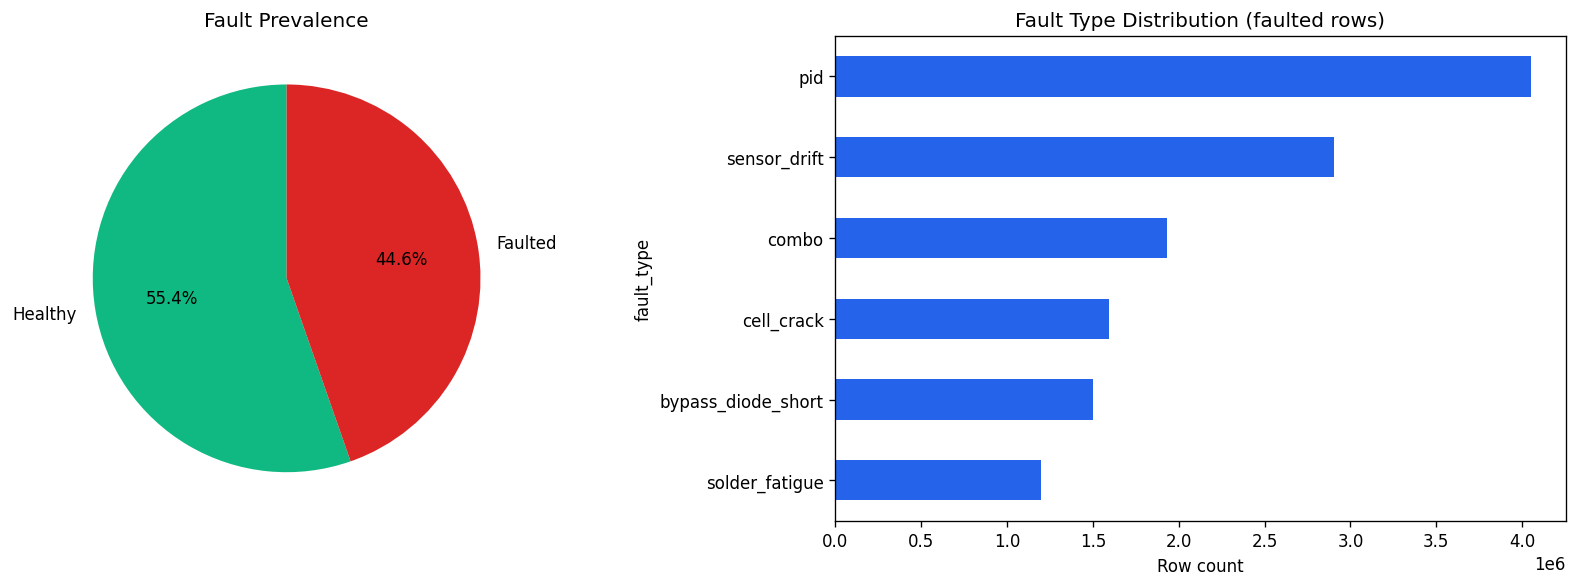

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fault prevalence
ax = axes[0]
labels = ["Healthy", "Faulted"]
sizes  = [len(df_explore) - len(faulted), len(faulted)]
ax.pie(sizes, labels=labels, autopct="%1.1f%%",
       colors=["#10b981", "#dc2626"], startangle=90)
ax.set_title("Fault Prevalence")

# Fault type breakdown
ax = axes[1]
vc.plot(kind="barh", ax=ax, color="#2563eb")
ax.set_xlabel("Row count")
ax.set_title("Fault Type Distribution (faulted rows)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fault_distribution.png", bbox_inches="tight")
plt.show()


## 7. Temporal overview

In [8]:
if "sim_year" in df_explore.columns:
    year_counts = df_explore.groupby("sim_year")["fault_active"].agg(["sum", "count"])
    year_counts["fault_rate"] = year_counts["sum"] / year_counts["count"]
    display(year_counts)


,sum,count,fault_rate
sim_year,,,
1,1483631,4923803,0.301318
2,1769640,4924770,0.359335
3,2402889,4930966,0.487306
4,2509896,4918186,0.510330
5,2511752,4920874,0.510428
6,2506106,4910962,0.510309


## 8. Apply feature engineering & inspect new features

In [9]:
df = add_features(df_explore.copy(), cfg.array_kwp)
new_cols = ["hour_sin", "hour_cos", "doy_sin", "doy_cos",
            "performance_ratio", "pr_deviation",
            "dc_ac_power_ratio", "power_step"]
df[new_cols].describe().round(4)


After daytime filter: 29,529,561 rows


,hour_sin,hour_cos,doy_sin,doy_cos,performance_ratio,pr_deviation,dc_ac_power_ratio,power_step
count,2.952956e+07,2.952956e+07,2.952956e+07,2.952956e+07,2.952956e+07,2.952956e+07,2.952956e+07,2.952956e+07
mean,-6.010000e-01,1.104000e-01,1.490000e-02,-9.190000e-02,7.883000e-01,1.000000e+00,1.122500e+00,4.960000e-01
std,3.837000e-01,6.924000e-01,7.079000e-01,7.002000e-01,1.762000e-01,2.234000e-01,2.802000e-01,1.874000e-01
min,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,9.643000e-01,0.000000e+00
25%,-9.239000e-01,-5.556000e-01,-6.933000e-01,-7.776000e-01,7.556000e-01,9.485000e-01,1.042100e+00,3.487000e-01
50%,-7.224000e-01,1.736000e-01,2.580000e-02,-1.840000e-01,8.520000e-01,1.056900e+00,1.056500e+00,5.261000e-01
75%,-3.624000e-01,8.064000e-01,7.236000e-01,5.982000e-01,8.969000e-01,1.132000e+00,1.087400e+00,6.318000e-01
max,8.434000e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.136200e+00,2.102100e+00,5.000000e+00,1.086000e+00


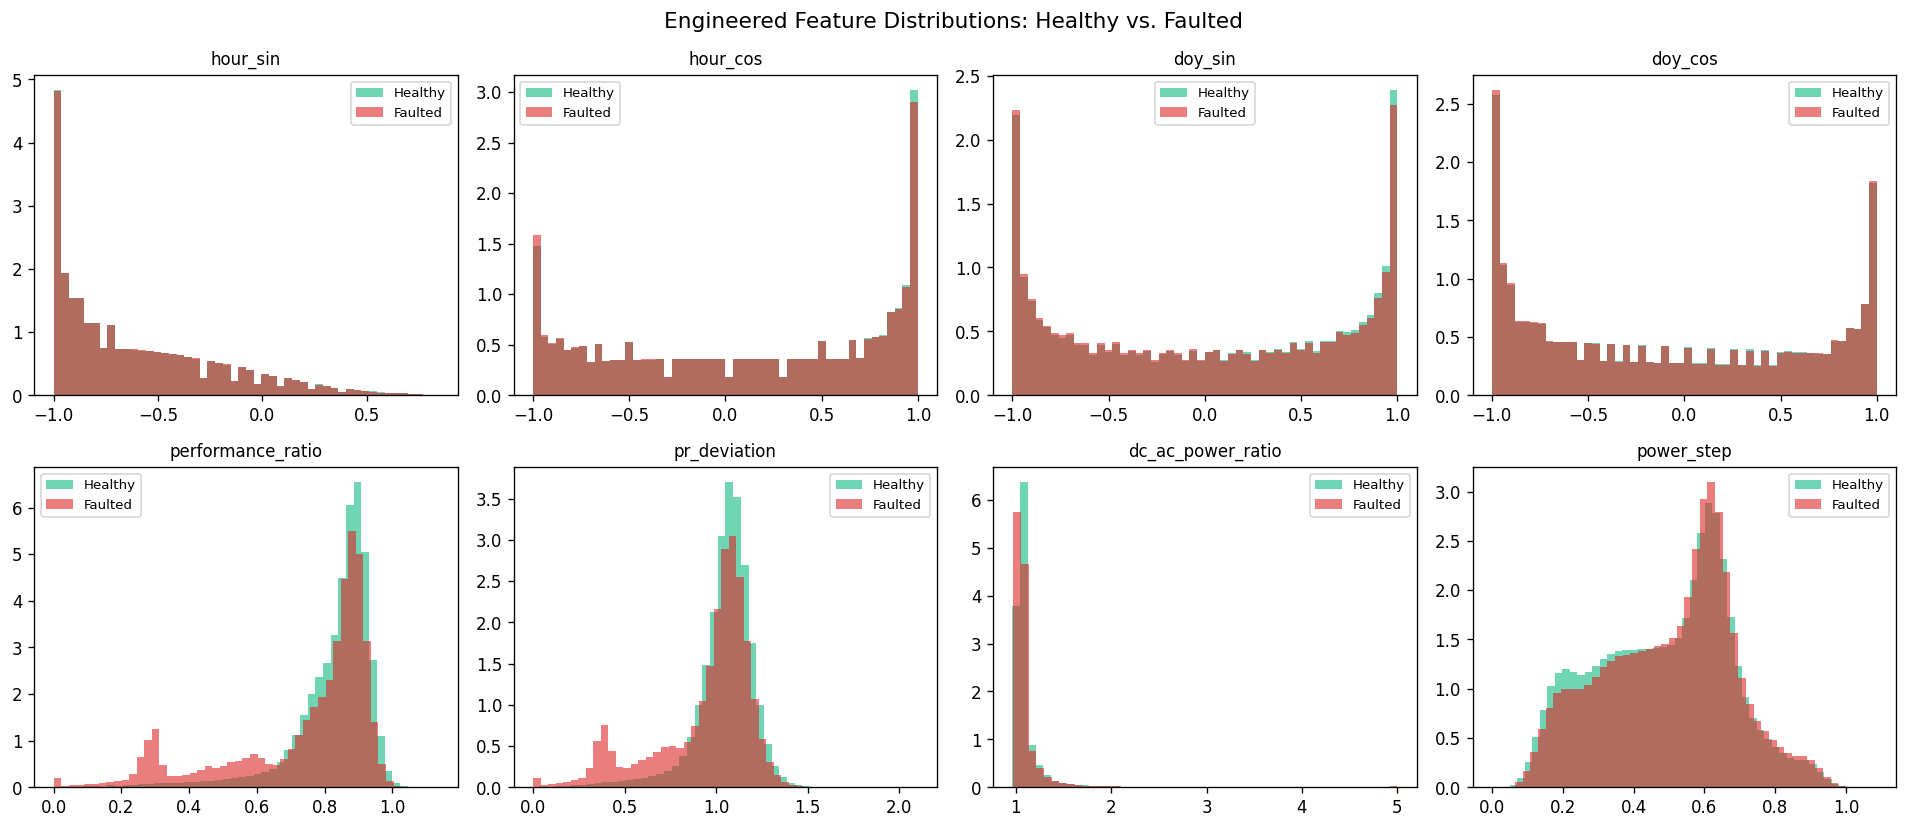

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, col in zip(axes, new_cols):
    healthy = df[~df["fault_active"]][col].dropna()
    bad     = df[ df["fault_active"]][col].dropna()
    ax.hist(healthy, bins=50, alpha=0.6, label="Healthy", color="#10b981",
            density=True)
    ax.hist(bad,     bins=50, alpha=0.6, label="Faulted", color="#dc2626",
            density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
plt.suptitle("Engineered Feature Distributions: Healthy vs. Faulted",
             fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_distributions.png", bbox_inches="tight")
plt.show()


## 9. Correlation heatmap (SCADA features)

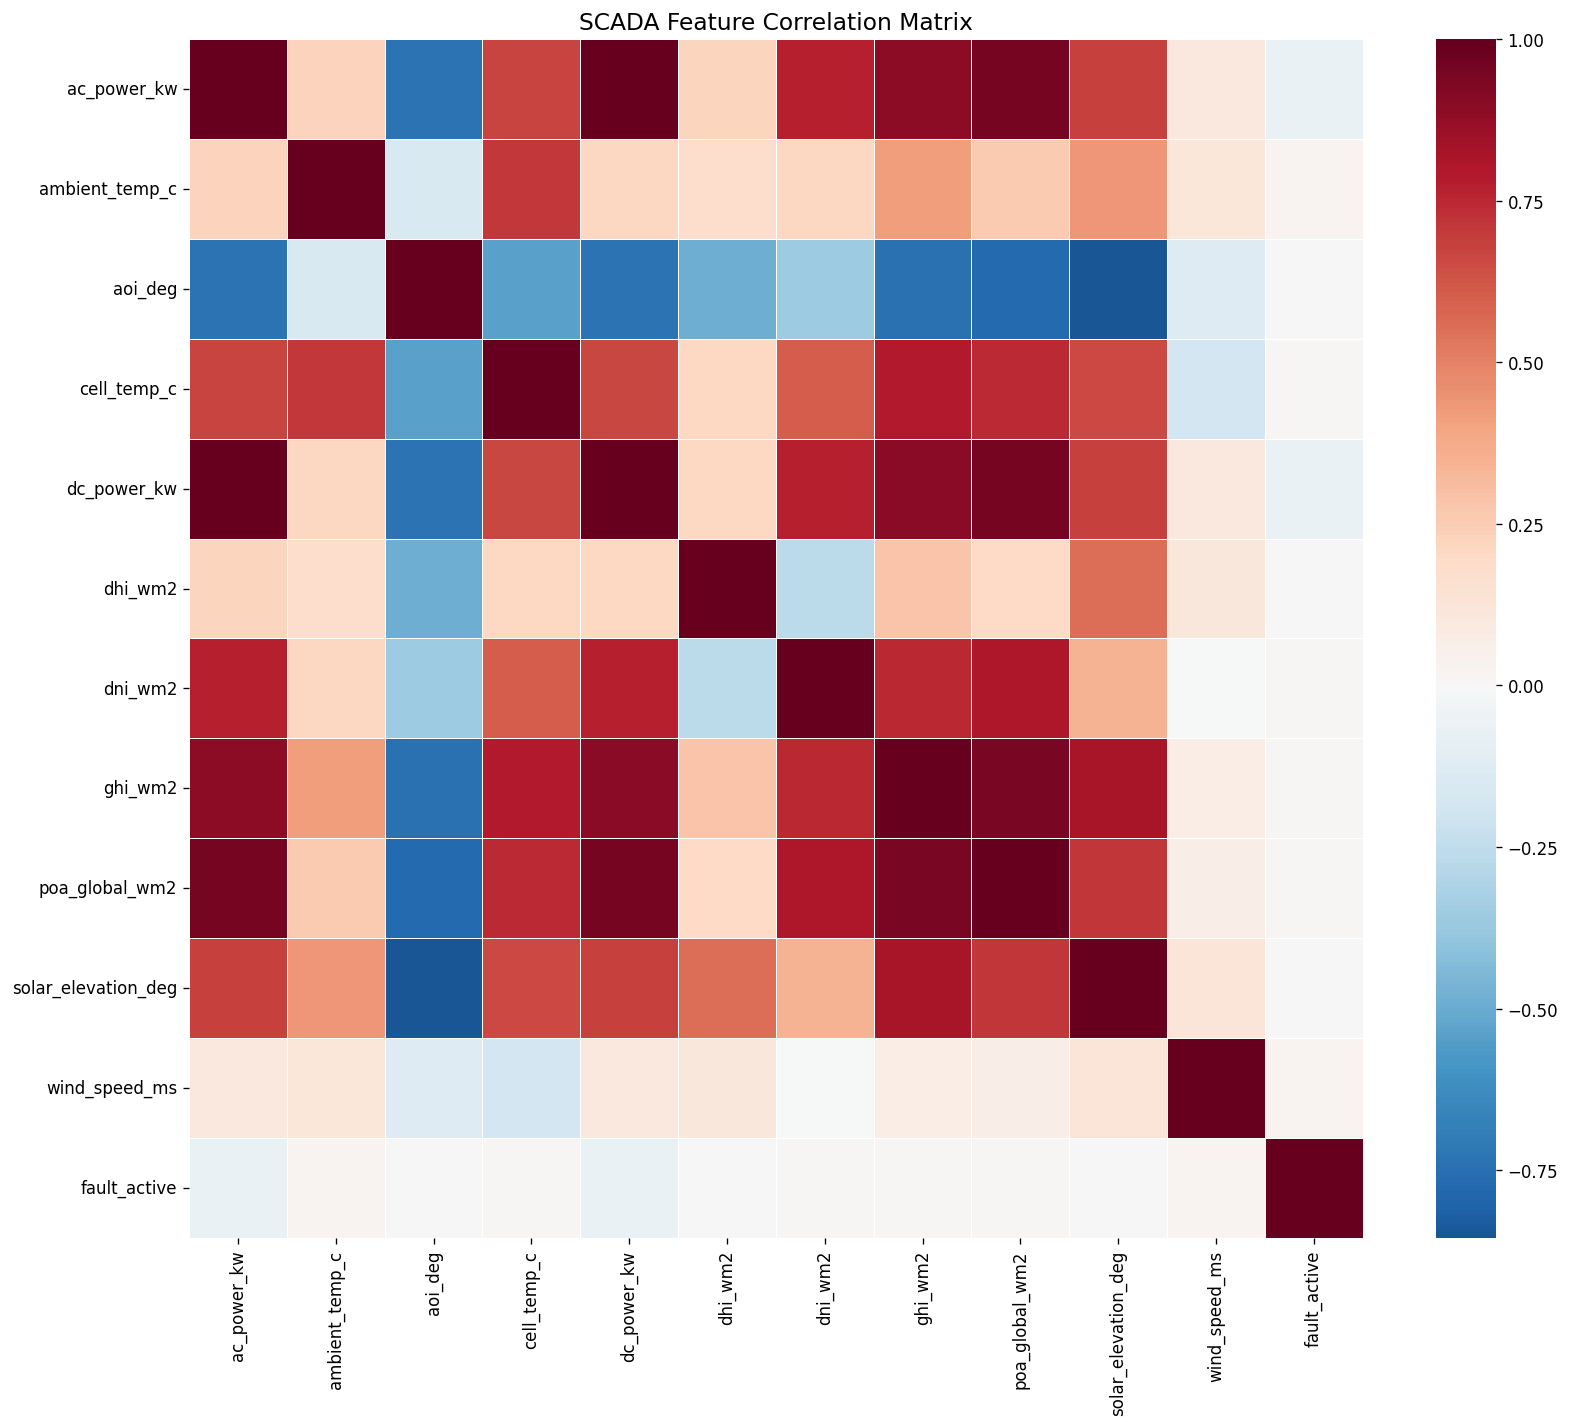

In [11]:
import seaborn as sns

scada_cols = [c for c in cfg.scada_features if c in df.columns]
corr = df[scada_cols + ["fault_active"]].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0,
            linewidths=0.3, ax=ax)
ax.set_title("SCADA Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/correlation_heatmap.png", bbox_inches="tight")
plt.show()


## 10. Sample time-series: one run

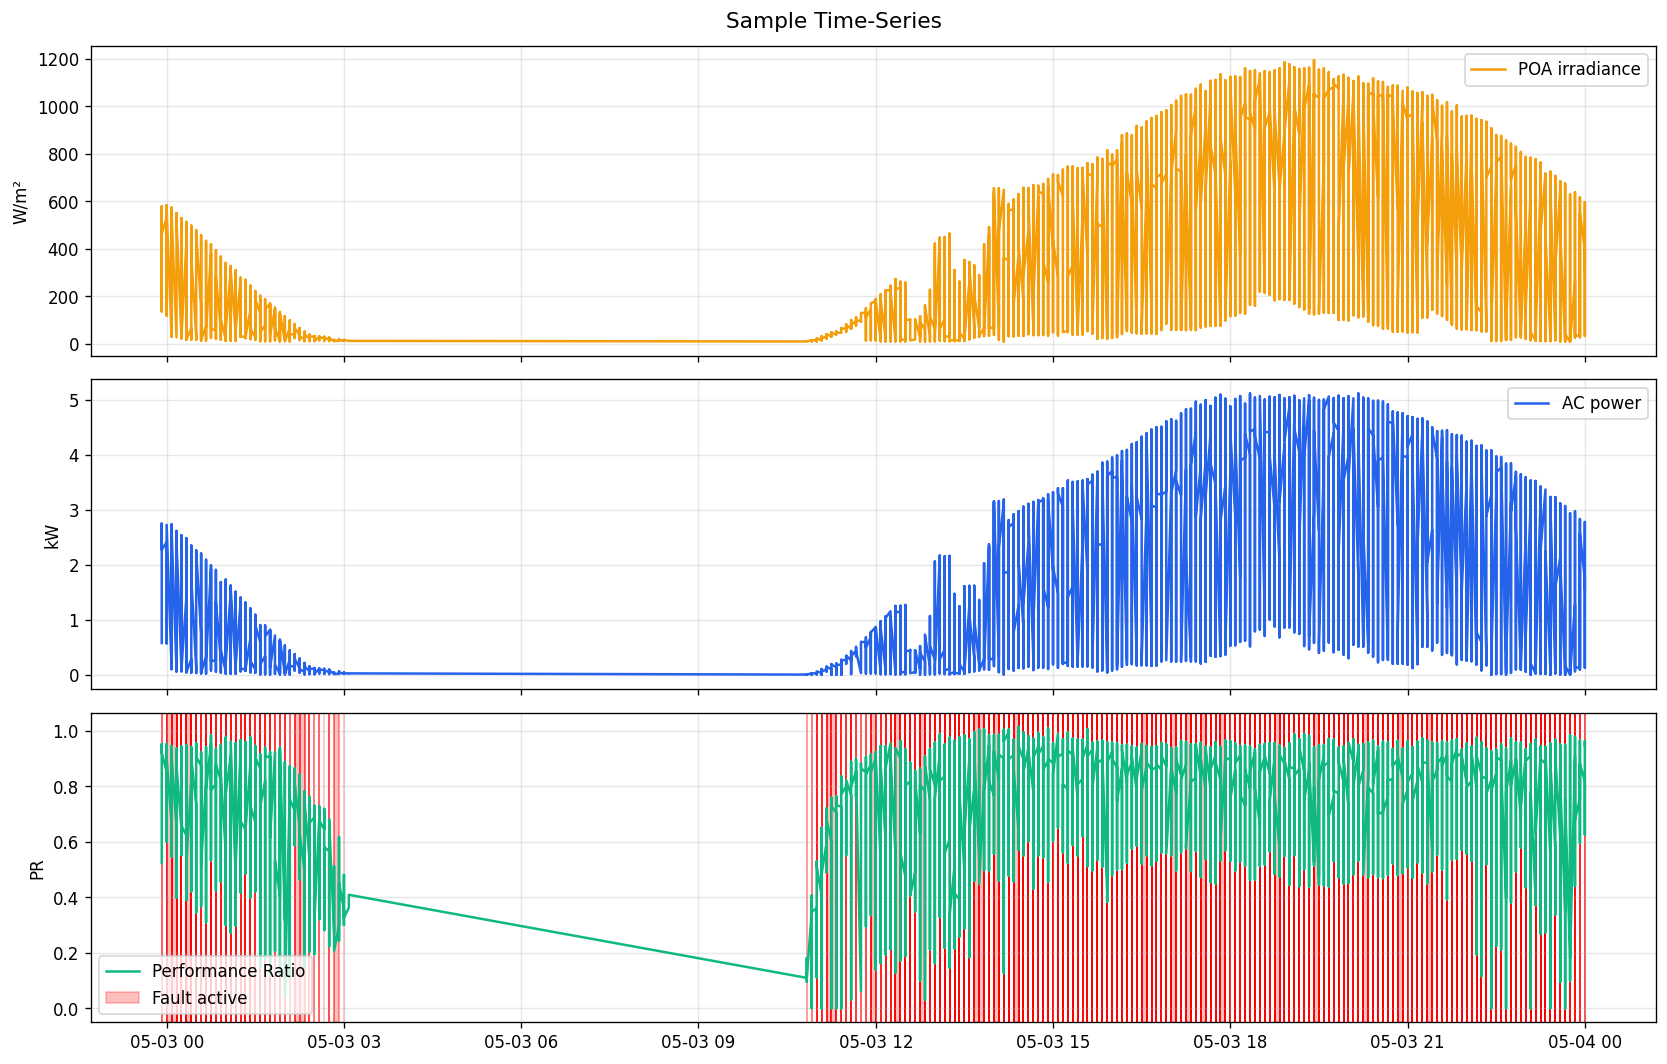

In [12]:
if "sim_day" in df.columns:
    # Pick one day from one run
    sample = df[df["sim_day"] == df["sim_day"].iloc[100]].copy()
    sample = sample.sort_values("timestamp")

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(sample["timestamp"], sample["poa_global_wm2"],
                 color="#f59e0b", label="POA irradiance")
    axes[0].set_ylabel("W/m²"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(sample["timestamp"], sample["ac_power_kw"],
                 color="#2563eb", label="AC power")
    axes[1].set_ylabel("kW"); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(sample["timestamp"], sample["performance_ratio"],
                 color="#10b981", label="Performance Ratio")
    # Shade faulted periods
    if sample["fault_active"].any():
        fa = sample["fault_active"].values
        ts = sample["timestamp"].values
        axes[2].fill_between(ts, 0, 1,
                             where=fa, alpha=0.25, color="red",
                             label="Fault active", transform=axes[2].get_xaxis_transform())
    axes[2].set_ylabel("PR"); axes[2].legend(); axes[2].grid(alpha=0.3)

    fig.suptitle("Sample Time-Series", fontsize=13)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/sample_timeseries.png", bbox_inches="tight")
    plt.show()
else:
    print("sim_day column not present — skipping time-series plot.")
